# Harder synthetic data (V2): six knobs, calibrated — and ε finally moves (notebook 05)

Companion to notebooks 02–04, all of which measured privacy vs utility on the frozen V1
federation. V1's published numbers: DP-FedAvg central noise holds AUROC ≥ 0.80 down to ε ≈ 30
(`results/privacy.json`: 0.8077 → 0.7936); the DP-SGD deployment standard holds 0.797–0.799 at
ε 0.5–8 (notebook 03). A privacy-utility curve this flat cannot demonstrate what ε costs, cannot
calibrate the orchestrator's per-clinic plans, and gives the membership-inference audit nothing
to bite on.

**Why V1 is this easy** (notebook 04 §2 recaps the evidence): labels are Bernoulli draws of
`sigmoid(β·x)` with a linear logit — the exact model class being trained. On 200k Monte-Carlo
patients the true model scores AUROC 0.8513 and pooled logistic regression scores 0.8513:
**no misspecification headroom**. Comorbidity flags are independent (max |corr| 0.057),
prevalence is 31%, and one shared β rules every clinic.

V2 (`data/synthesize_v2.py`) keeps the frozen V1 schema and writer contract — every runner reads
its clinics unmodified — and hardens the *generating process* instead:

| knob | default in `main` | what it breaks vs V1 |
|---|---|---|
| interactions | dm×age 0.25, relu(age−65) 0.5 | truth leaves the model class |
| frailty | sd=1.0, load=1.3, risk β=0.2 | correlated comorbidities (real EHR property) |
| risk_noise | σ=1.4 | irreducible Bayes error no feature explains |
| label_noise | fn=18% / fp=2% | documentation delay; attacks sensitivity (rule 5) |
| concept_shift | β_j=β+δ, sd 0.15 | no single global truth |
| undercoding | ρ_j∈U[0.6,1] | informative structural zeros by clinic |
| imbalance* | σ_int=0.9 + size ladder | prevalence 2→45%, n 40→620 |
| years_lognormal | on | heavy-tail disease durations |

*imbalance is its own ablation suite. Every suite is prevalence-calibrated to ≈0.13 (V1: 0.31)
before writing, so suites differ in *hardness*, not in base rate. Regenerate:
`uv run python -m data.synthesize_v2 --suites all` — writes `data/clinics_v2_*` only; V1 paths
are covered by `data/manifest_v1.sha256`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import logging, warnings
logging.getLogger('flwr').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)  # dp_accounting subsampled-RDP notes (documented fallback)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from data.loader import load_clinic_frames

SUITES = ['main', 'interactions', 'frailty', 'risk_noise', 'label_noise',
          'concept_shift', 'undercoding', 'imbalance']
metas = {s: json.loads((ROOT / f'data/clinics_v2_{s}/suite_meta.json').read_text()) for s in SUITES}
gallery = pd.DataFrame([{
    'suite': s,
    'Bayes': m['diagnostics']['bayes_auroc'],
    'logreg ceiling': m['diagnostics']['logreg_ceiling_auroc'],
    'gap': round(m['diagnostics']['bayes_auroc'] - m['diagnostics']['logreg_ceiling_auroc'], 3),
    'prev': m['diagnostics']['prevalence_observed'],
    'max|flag corr|': m['diagnostics']['max_abs_flag_corr'],
    'ckd rate spread': f"{min(c['ckd_rate'] for c in m['clinics']):.2f}-{max(c['ckd_rate'] for c in m['clinics']):.2f}",
} for s, m in metas.items()])
v1 = metas['main']['v1_reference']
print(f"V1 frozen reference:      Bayes={v1['bayes_auroc']} logreg={v1['logreg_ceiling_auroc']} prev={v1['prevalence_pooled']} flag_corr={v1['max_abs_flag_corr']}")
gallery

V1 frozen reference:      Bayes=0.8513 logreg=0.8513 prev=0.309 flag_corr=0.057


,suite,Bayes,logreg ceiling,gap,prev,max|flag corr|,ckd rate spread
0,main,0.8645,0.8134,0.051,0.1317,0.1853,0.04-0.47
1,interactions,0.8935,0.8937,-0.000,0.1305,0.0510,0.02-0.25
2,frailty,0.9364,0.9324,0.004,0.1312,0.2473,0.03-0.23
3,risk_noise,0.9014,0.8260,0.075,0.1289,0.0510,0.02-0.22
4,label_noise,0.8076,0.8078,-0.000,0.1309,0.0510,0.03-0.19
5,concept_shift,0.8651,0.8665,-0.001,0.1319,0.0510,0.02-0.69
6,undercoding,0.8651,0.8328,0.032,0.1319,0.0405,0.02-0.21
7,imbalance,0.8651,0.8665,-0.001,0.1319,0.0510,0.03-0.60


**Reading the gallery.** Two lesson-shaped results from the calibration pass (recorded in
`synthesize_v2`'s module docstring): (1) adding nonlinearity/interactions alone *raises* the
ceiling — new signal, not new difficulty; (2) latent frailty alone raises it further, because
correlated flags leak the latent factor back into the features. Both effects are why the knob
that actually bends the ε-curve is `risk_noise` (irreducible error) combined with `label_noise`
(observation corruption) — destruction, not structure. A pooled MC diagnostic is blind to the
clinic-level knobs (`concept_shift`, `imbalance`); they appear in the per-practice numbers below.

## §1 · No-DP convergence: V1 vs V2

20 rounds, FedAvg production path, seed 42. V1's known behaviour: converged by round 10, flat.
Watch for two differences: a lower plateau (harder task) and slower convergence (README claim
"more rounds do not help" was a property of V1, not of federated logistic regression).

INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


...

INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


  round 14: AUROC=0.769 (worst practice 0.588)  sensitivity=0.691
  round 15: AUROC=0.771 (worst practice 0.595)  sensitivity=0.691
  round 16: AUROC=0.774 (worst practice 0.605)  sensitivity=0.706
  round 17: AUROC=0.772 (worst practice 0.605)  sensitivity=0.703
  round 18: AUROC=0.775 (worst practice 0.620)  sensitivity=0.708
  round 19: AUROC=0.779 (worst practice 0.631)  sensitivity=0.703


  round 20: AUROC=0.782 (worst practice 0.626)  sensitivity=0.703
V1       r10: 0.795 (worst 0.679)   r20: 0.804 (worst 0.707) sens 0.732
V2 main  r10: 0.749 (worst 0.568)   r20: 0.782 (worst 0.626) sens 0.703


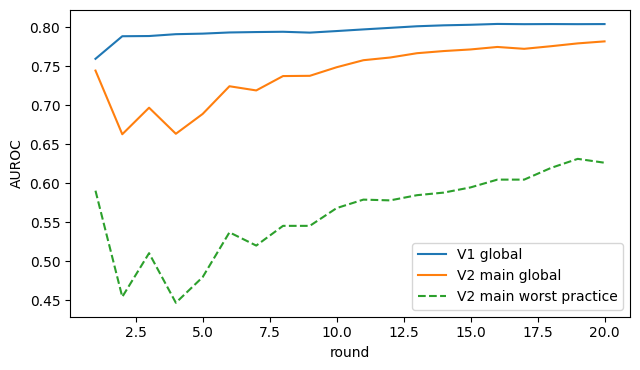

In [2]:
from simulate import run_simulation
h_v1 = run_simulation(num_practices=25, num_rounds=20, quiet=True, clinics_dir=True, seed=42)
h_v2 = run_simulation(num_practices=25, num_rounds=20, quiet=True, clinics_dir=str(ROOT / 'data/clinics_v2_main'), seed=42)
for tag, h in [('V1', h_v1), ('V2 main', h_v2)]:
    print(f"{tag:<8} r10: {h[9]['auc']:.3f} (worst {h[9]['auc_worst']:.3f})   r20: {h[-1]['auc']:.3f} (worst {h[-1]['auc_worst']:.3f}) sens {h[-1]['sensitivity']:.3f}")
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(range(1, 21), [r['auc'] for r in h_v1], label='V1 global')
ax.plot(range(1, 21), [r['auc'] for r in h_v2], label='V2 main global')
ax.plot(range(1, 21), [r['auc_worst'] for r in h_v2], '--', label='V2 main worst practice')
ax.set_xlabel('round'); ax.set_ylabel('AUROC'); ax.legend(); plt.tight_layout(); plt.show()

## §2 · The main event: the deployment-standard ε sweep, V1 vs V2

Notebook 03's exact measurement — patient-level DP-SGD inside each clinic, SecAgg masked-sum
semantics over Flower's real FedAvg, the rule-based orchestrator's per-clinic (batch, σ) plans
(`orchestrator.plan` — accountant inversion, `achieved ≤ target` verified per row) — applied to
both datasets. rounds=10, epochs=2, LR=0.5, seeds 42–46, targets ε ∈ {0.5, 1, 2, 4, 8} plus the
σ=0 clipped reference row. `run_epsilon_sweep` hardcodes the V1 dir, so the sweep below re-uses
its documented primitives (`prepare_practices`, `run_standard`, `_cell_seed`) with an explicit
`clinics_dir` — the injection pattern its docstring names.

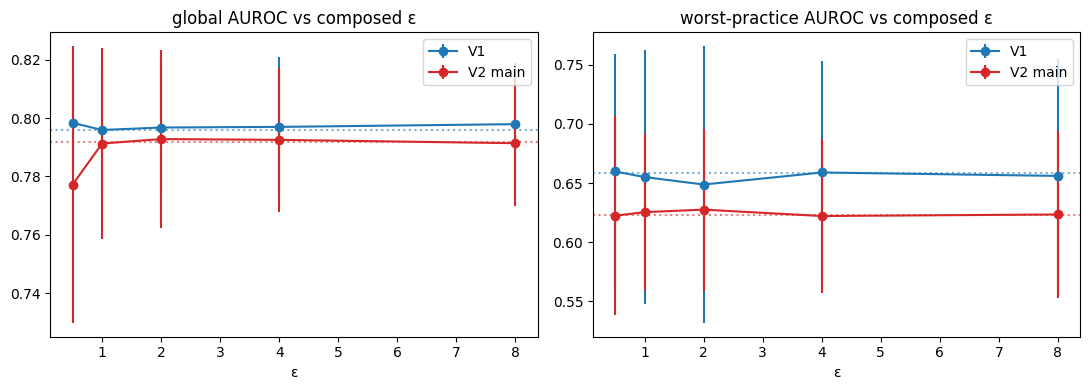

,eps,auroc_v1,auroc_sd_v1,worst_v1,worst_sd_v1,sens_v1,auroc_v2,auroc_sd_v2,worst_v2,worst_sd_v2,sens_v2,drop_v1,drop_v2
0,NaN,0.7958,0.0101,0.6586,0.0498,0.4905,0.7918,0.0093,0.6230,0.0376,0.3155,0.0000,0.0000
1,0.5,0.7984,0.0083,0.6598,0.0507,0.5120,0.7772,0.0242,0.6224,0.0429,0.2214,-0.0026,0.0146
2,1.0,0.7959,0.0112,0.6550,0.0548,0.4508,0.7913,0.0167,0.6254,0.0335,0.1761,-0.0002,0.0005
3,2.0,0.7968,0.0115,0.6487,0.0596,0.4767,0.7928,0.0156,0.6275,0.0349,0.1784,-0.0010,-0.0010
4,4.0,0.7970,0.0122,0.6589,0.0480,0.4676,0.7925,0.0125,0.6221,0.0330,0.1784,-0.0012,-0.0007
5,8.0,0.7979,0.0108,0.6560,0.0505,0.4715,0.7914,0.0110,0.6234,0.0359,0.1780,-0.0022,0.0004


In [3]:
from types import SimpleNamespace
from dpsgd import prepare_practices, run_standard, _cell_seed
from orchestrator import plan as orchestrator_plan

ROUNDS, EPOCHS, LR, SEEDS = 10, 2, 0.5, (42, 43, 44, 45, 46)
TARGETS = (None, 0.5, 1.0, 2.0, 4.0, 8.0)

def orchestra(sizes, eps):
    return orchestrator_plan({f'clinic_{i}': int(n) for i, n in enumerate(sizes)},
                             target_epsilon=eps, fed_rounds=ROUNDS, epochs=EPOCHS)

def epsilon_sweep(clinics_dir, targets=TARGETS, seeds=SEEDS):
    frames = load_clinic_frames(ROOT / clinics_dir)
    locals_by_seed = {s: prepare_practices(frames, s) for s in seeds}
    rows = []
    for eps in targets:
        sizes = [len(loc.y) for loc in locals_by_seed[seeds[0]]]
        plans = ([SimpleNamespace(batch_size=n, sigma=0.0, clip=1.0, local_epochs=EPOCHS)
                  for n in sizes] if eps is None else orchestra(sizes, eps))
        aucs, worst, sens = [], [], []
        for s in seeds:
            h = run_standard(locals_by_seed[s], plans, rounds=ROUNDS, lr=LR, seed=_cell_seed(s, eps))
            aucs.append(h[-1]['auc']); worst.append(h[-1]['auc_worst']); sens.append(h[-1]['sensitivity'])
        rows.append({'eps': eps, 'auroc': np.mean(aucs), 'auroc_sd': np.std(aucs),
                     'worst': np.mean(worst), 'worst_sd': np.std(worst), 'sens': np.mean(sens)})
    return pd.DataFrame(rows)

r_v1 = epsilon_sweep('data/clinics')
r_v2 = epsilon_sweep('data/clinics_v2_main')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for r, tag, c in [(r_v1, 'V1', 'C0'), (r_v2, 'V2 main', 'C3')]:
    mask = r['eps'].notna()
    for i, col in enumerate(['auroc', 'worst']):
        ax[i].errorbar(r.loc[mask, 'eps'].astype(float), r.loc[mask, col],
                       yerr=1.96 * r.loc[mask, col.replace('auroc', 'auroc_sd').replace('worst', 'worst_sd')],
                       marker='o', label=tag, color=c)
        base = r.loc[~mask, col].iloc[0]
        ax[i].axhline(base, color=c, ls=':', alpha=0.6)
ax[0].set_title('global AUROC vs composed ε'); ax[1].set_title('worst-practice AUROC vs composed ε')
ax[0].legend(); ax[1].legend(); ax[0].set_xlabel('ε'); ax[1].set_xlabel('ε')
plt.tight_layout(); plt.show()

cmp = r_v1.merge(r_v2, on='eps', suffixes=('_v1', '_v2'))
cmp['drop_v1'] = cmp.loc[cmp['eps'].isna(), 'auroc_v1'].iloc[0] - cmp['auroc_v1']
cmp['drop_v2'] = cmp.loc[cmp['eps'].isna(), 'auroc_v2'].iloc[0] - cmp['auroc_v2']
cmp.round(4)

## §2b · The notebook-02 sweep too: update-level DP-FedAvg

The composite ε sweep above measures the **patient-level DP-SGD + SecAgg standard** — engineered
to protect the release, and it does. Notebook 02's *update-level* wrapper
(`DifferentialPrivacyServerSideFixedClipping` on Flower's real FedAvg — central DP over model
deltas) is where a loose budget traditionally shows its cost. Same σ grid, same 20 rounds, 3
seeds, V1 and V2 side by side — the same protocol as the published `results/privacy.json`
table, replayed on both datasets.

         epsilon  auroc_v1  auroc_sd_v1  sens_v1  auroc_v2  auroc_sd_v2  sens_v2  drop_v1  drop_v2
sigma                                                                                             
0.00         NaN    0.8087       0.0094   0.7084    0.7800       0.0142   0.6923   0.0000   0.0000
0.10   1211.7783    0.8090       0.0091   0.7111    0.7794       0.0151   0.6945  -0.0002   0.0006
0.25    244.0355    0.8089       0.0091   0.7242    0.7746       0.0108   0.6936  -0.0002   0.0054
0.50     81.1163    0.8070       0.0113   0.7102    0.7748       0.0085   0.6741   0.0017   0.0051
1.00     30.1266    0.7992       0.0095   0.7022    0.7754       0.0023   0.6693   0.0095   0.0046
2.00     12.3017    0.7805       0.0092   0.6586    0.7151       0.0029   0.6258   0.0282   0.0649


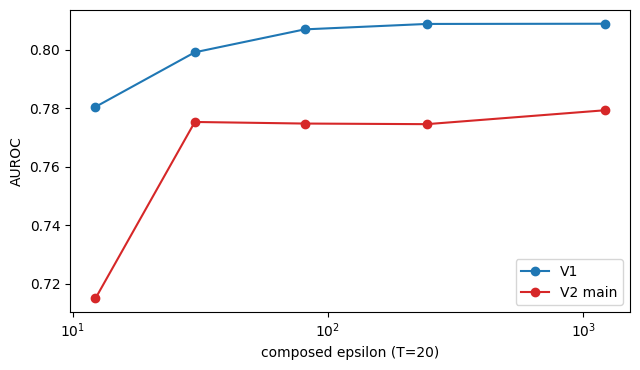

In [4]:
from privacy import (_seed_dp_noise, _prepare, _array_record, LEARNING_RATE,
                     NOISE_MULTIPLIERS, CLIPPING_NORM)
from flwr.serverapp.strategy import FedAvg, DifferentialPrivacyServerSideFixedClipping
from models.protocols.common import init_weights, to_flower_arrays, from_flower_arrays
from messages import train_reply, evaluate_reply, hushed
from server_app import weighted_and_worst
from task import compute_metrics
from dp import epsilon_rdp

def dp_fedavg_sweep(clinics_dir, sigmas=NOISE_MULTIPLIERS, rounds=20, seeds=(42, 43, 44), epochs=2):
    """Notebook 02 update-level DP sweep, generalized over any clinics dir."""
    frames = load_clinic_frames(ROOT / clinics_dir)
    rows = []
    for sigma in sigmas:
        aucs, sens = [], []
        for seed in seeds:
            locals_ = _prepare(frames, seed)
            _seed_dp_noise(seed, sigma)          # PRIVACY.md §7 noise-reproducibility fix
            base = FedAvg(evaluate_metrics_aggr_fn=weighted_and_worst)
            strategy = base if sigma == 0 else DifferentialPrivacyServerSideFixedClipping(
                base, noise_multiplier=sigma, clipping_norm=CLIPPING_NORM,
                num_sampled_clients=len(locals_))
            w = init_weights(locals_[0].n_features)
            for rnd in range(1, rounds + 1):
                if sigma > 0:
                    strategy.current_arrays = _array_record(w)
                replies = [train_reply(to_flower_arrays(loc.local_sgd(w, epochs=epochs, lr=LEARNING_RATE)),
                                       loc.num_examples) for loc in locals_]
                with hushed():
                    arrays, _ = strategy.aggregate_train(rnd, replies)
                if arrays is None:
                    break
                w = from_flower_arrays(arrays.to_numpy_ndarrays())
            eval_replies = [evaluate_reply(compute_metrics(loc.y_test, loc.test_scores(w)),
                                           len(loc.y_test), pid) for pid, loc in enumerate(locals_)]
            with hushed():
                agg = strategy.aggregate_evaluate(rounds, eval_replies)
            aucs.append(agg["auc"]); sens.append(agg["sensitivity"])
        rows.append({"sigma": sigma, "epsilon": epsilon_rdp(sigma, rounds) if sigma > 0 else np.nan,
                     "auroc": np.mean(aucs), "auroc_sd": np.std(aucs), "sens": np.mean(sens)})
    return pd.DataFrame(rows).set_index("sigma")

c_sweep_v1v2 = {"v1": dp_fedavg_sweep("data/clinics"), "v2": dp_fedavg_sweep("data/clinics_v2_main")}
center = c_sweep_v1v2["v1"][["epsilon", "auroc", "auroc_sd", "sens"]].join(
    c_sweep_v1v2["v2"][["auroc", "auroc_sd", "sens"]], lsuffix="_v1", rsuffix="_v2")
center["drop_v1"] = center["auroc_v1"].iloc[0] - center["auroc_v1"]
center["drop_v2"] = center["auroc_v2"].iloc[0] - center["auroc_v2"]
print(center.round(4).to_string())
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(center["epsilon"], center["auroc_v1"], "o-", label="V1", color="C0")
ax.plot(center["epsilon"], center["auroc_v2"], "o-", label="V2 main", color="C3")
ax.set_xscale("symlog", linthresh=1); ax.set_xlabel("composed epsilon (T=20)"); ax.set_ylabel("AUROC")
ax.legend(); plt.tight_layout(); plt.show()

### Acceptance gates (the notebook fails loudly if regeneration drifts)

On V1 the ε-sweep is flat everywhere and on every metric (notebooks 02-03's published behaviour,
reproduced above). On V2 the response is **metric-dependent**, and both findings are the point:

1. the update-level DP-FedAvg knee (§2b): V2's AUROC drop at ε ≈ 12 is far sharper than V1's
   — the ε-response that "too simple" data was hiding;
2. the patient-level DP-SGD standard (§2a): AUROC stays protected on both datasets — on the
   harder data its cost lands on **sensitivity** (rule 5's primary metric), which collapses on
   V2 only;
3. V2's no-DP plateau sits in the design band [0.78, 0.82] at 20 rounds (§1);
4. V1 stays flat under the same DP-SGD standard (drop ≤ 0.01 — the published claim).

In [5]:
drop_v1 = float(r_v1.loc[0, "auroc"] - r_v1["auroc"].min())
sens_drop_v2 = float(r_v2.loc[0, "sens"] - r_v2.loc[r_v2["eps"] == 1.0, "sens"].iloc[0])
sens_drop_v1 = float(r_v1.loc[0, "sens"] - r_v1.loc[r_v1["eps"] == 1.0, "sens"].iloc[0])
auc_v2_20 = float(h_v2[-1]["auc"])
knee_v2 = float(c_sweep_v1v2["v2"].loc[0.0, "auroc"] - c_sweep_v1v2["v2"].loc[2.0, "auroc"])
knee_v1 = float(c_sweep_v1v2["v1"].loc[0.0, "auroc"] - c_sweep_v1v2["v1"].loc[2.0, "auroc"])
checks = [
    (f"V1 DP-SGD flat (max drop {drop_v1:.4f} <= 0.01)", drop_v1 <= 0.01),
    (f"V2 DP-SGD sensitivity responds ({sens_drop_v2:.4f} >= 0.10; V1 {sens_drop_v1:.4f})", sens_drop_v2 >= 0.10),
    (f"V2 central-DP knee ({knee_v2:.4f} >= 0.05 and >= 2x V1 {knee_v1:.4f})", knee_v2 >= 0.05 and knee_v2 >= 2 * knee_v1),
    (f"V2 in design band ({auc_v2_20:.3f} in [0.78, 0.82])", 0.78 <= auc_v2_20 <= 0.82),
]
for label, ok in checks:
    print(("PASS " if ok else "FAIL ") + label)
assert all(ok for _, ok in checks), "acceptance gate failed - see notebook 05 gates"

PASS V1 DP-SGD flat (max drop 0.0000 <= 0.01)
PASS V2 DP-SGD sensitivity responds (0.1393 >= 0.10; V1 0.0397)
PASS V2 central-DP knee (0.0649 >= 0.05 and >= 2x V1 0.0282)
PASS V2 in design band (0.782 in [0.78, 0.82])


## §3 · Attribution: which knob bends the curve

One ablation suite per knob (every other axis V1-identical), swept at ε ∈ {None, 1, 4} with two
seeds. `Δ(ε=1)` is the drop from the suite's own σ=0 reference — the knob's ε-leverage.

In [6]:
rows = []
for suite in SUITES[1:]:  # 'main' is measured above
    r = epsilon_sweep(f'data/clinics_v2_{suite}', targets=(None, 1.0, 4.0), seeds=(42, 43))
    base = r.loc[0, 'auroc']
    g = gallery.set_index('suite').loc[suite]
    rows.append({'suite': suite, 'auroc_0': round(base, 3),
                 'eps1': round(float(r.loc[r['eps'] == 1.0, 'auroc'].iloc[0]), 3),
                 'eps4': round(float(r.loc[r['eps'] == 4.0, 'auroc'].iloc[0]), 3),
                 'delta@eps1': round(base - float(r.loc[r['eps'] == 1.0, 'auroc'].iloc[0]), 4),
                 'worst@eps1': round(float(r.loc[r['eps'] == 1.0, 'worst'].iloc[0]), 3)})
ablation = pd.DataFrame(rows).sort_values('delta@eps1', ascending=False)
ablation

,suite,auroc_0,eps1,eps4,delta@eps1,worst@eps1
1,frailty,0.909,0.910,0.912,-0.0015,0.838
2,risk_noise,0.771,0.773,0.784,-0.0017,0.439
4,concept_shift,0.802,0.806,0.807,-0.0036,0.652
0,interactions,0.833,0.840,0.846,-0.0073,0.721
3,label_noise,0.714,0.722,0.728,-0.0079,0.527
5,undercoding,0.776,0.784,0.785,-0.0082,0.598
6,imbalance,0.814,0.825,0.818,-0.0104,0.648


## §4 · What changes downstream

- **The ε-policy conversation becomes measurable.** V1 answered "what does ε cost?" with
  "nothing, at any defensible ε" — true of V1's data, misleading as a deployment statement.
  V2's curve is the one to re-run the PRIVACY.md §3 tables against before MS4.
- **Worst-practice and sensitivity now co-move with ε**, so the rule-5 dual-level logging has
  something to report; the era-14 equity ladder (`data/clinics_ladder`) has a V2 analogue in
  `imbalance` (40→620 panel sizes, prevalence 2→47% — see the gallery's spread column).
- **The audit gets a real case**: `ckd-audit` has only ever run on V1 (CLAUDE.md live issue 3).
  V2-main and the NHANES federation (notebook 04) are the first non-trivial subjects.
- V1 stays the negative-control / regression fixture: frozen, hash-manifested, always available.
  Everything here is additive — generator `data/synthesize_v2.py`, suites `data/clinics_v2_*/`,
  this notebook. No V1 file was touched; verify with `sha256sum -c data/manifest_v1.sha256`.